### Import Python libraries

In [ ]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Integer, Categorical, Continuous
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

### Project paths and output folders

In [ ]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    markers = {"README.md", ".git", "requirements.txt"}
    for candidate in [start, *start.parents]:
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    return start

PROJECT_ROOT = find_project_root()
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DOCUMENTS_DIR = PROJECT_ROOT / "documents"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
RESULTS_DIR = OUTPUTS_DIR / "results"

for path in [DATA_PROCESSED_DIR, FIGURES_DIR, RESULTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

COUNTRY_DATA_PATH = DATA_RAW_DIR / "Country-data.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data path: {COUNTRY_DATA_PATH}")

Project root: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis
Raw data path: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\data\raw\Country-data.csv


### Load Data

In [ ]:
data = pd.read_csv(COUNTRY_DATA_PATH)
df = data.copy()
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### In the dataset, there are three characteristics - imports, exports, and health spending - presented as percentages of GDP per capita. To gain a clearer understanding of each country, we first need to determine the actual values of these features from the percentage figures.

In [ ]:
df["health"] = df["health"] * df["gdpp"] / 100
df["exports"] = df["exports"] * df["gdpp"] / 100
df["imports"] = df["imports"] * df["gdpp"] / 100

transformed_data_path = DATA_PROCESSED_DIR / "country_data_transformed.csv"
df.to_csv(transformed_data_path, index=False)

print(f"Saved transformed dataset to: {transformed_data_path}")
df.head()

Saved transformed dataset to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\data\processed\country_data_transformed.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553
1,Albania,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460
3,Angola,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200


### Visualization

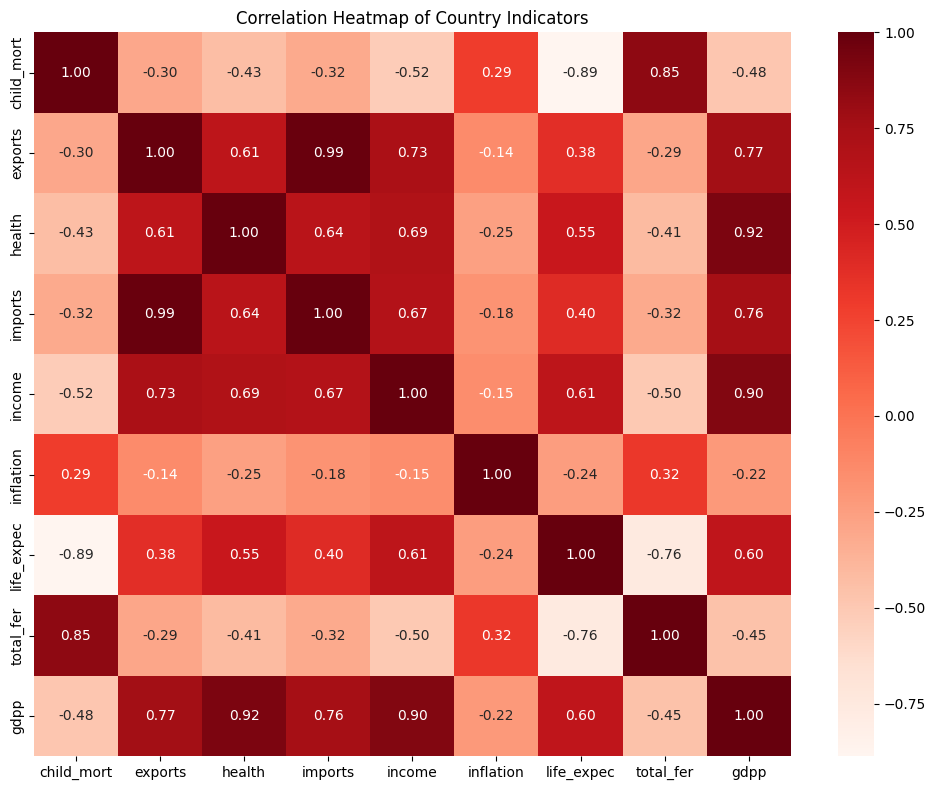

Saved figure to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\outputs\figures\correlation_heatmap.png


In [ ]:
correlations = df.drop("country", axis=1).corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="Reds")
plt.title("Correlation Heatmap of Country Indicators")
plt.tight_layout()

heatmap_path = FIGURES_DIR / "correlation_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {heatmap_path}")

In [ ]:
choropleth_dir = FIGURES_DIR / "choropleth_maps"
choropleth_dir.mkdir(parents=True, exist_ok=True)

for feature in df.drop("country", axis=1).columns:
    fig = px.choropleth(
        df,
        locationmode="country names",
        locations="country",
        projection="albers",
        title=f"{feature} per country",
        color=feature,
        color_continuous_scale="Teal",
    )
    fig.update_geos(fitbounds="locations", visible=True)
    fig.write_html(choropleth_dir / f"{feature}_map.html")
    fig.show()

print(f"Saved interactive choropleth maps to: {choropleth_dir}")

C:\Users\natha\AppData\Local\Temp\ipykernel_7568\1970050976.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


C:\Users\natha\AppData\Local\Temp\ipykernel_7568\1970050976.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


C:\Users\natha\AppData\Local\Temp\ipykernel_7568\1970050976.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


C:\Users\natha\AppData\Local\Temp\ipykernel_7568\1970050976.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


C:\Users\natha\AppData\Local\Temp\ipykernel_7568\1970050976.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


C:\Users\natha\AppData\Local\Temp\ipykernel_7568\1970050976.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


C:\Users\natha\AppData\Local\Temp\ipykernel_7568\1970050976.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


C:\Users\natha\AppData\Local\Temp\ipykernel_7568\1970050976.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


C:\Users\natha\AppData\Local\Temp\ipykernel_7568\1970050976.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


Saved interactive choropleth maps to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\outputs\figures\choropleth_maps


### Scale and Transform Data

In [ ]:
df2 = df.copy().set_index(keys="country", drop=True)

scaler = StandardScaler().fit(df2)
dftrans = scaler.transform(df2)
df1 = pd.DataFrame(dftrans, columns=df2.columns, index=df2.index)

scaled_data_path = DATA_PROCESSED_DIR / "country_data_scaled.csv"
df1.to_csv(scaled_data_path)

print(f"Saved scaled dataset to: {scaled_data_path}")
df1.head()

Saved scaled dataset to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\data\processed\country_data_scaled.csv


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,1.291532,-0.411011,-0.565040,-0.432276,-0.808245,0.157336,-1.619092,1.902882,-0.679180
Albania,-0.538949,-0.350191,-0.439218,-0.313677,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
Algeria,-0.272833,-0.318526,-0.484826,-0.353720,-0.220844,0.789274,0.670423,-0.038404,-0.465376
Angola,2.007808,-0.291375,-0.532363,-0.345953,-0.585043,1.387054,-1.179234,2.128151,-0.516268
Antigua and Barbuda,-0.695634,-0.104331,-0.178771,0.040735,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### Clustering Models

#### PCA

In [ ]:
pca = PCA(n_components=9) 
pcadf = pd.DataFrame(pca.fit_transform(df1), columns=[f"pc{i}" for i in range(1,10)], index=df1.index)
pca.explained_variance_

array([5.33631081e+00, 1.67006556e+00, 8.97406142e-01, 5.49797220e-01,
       2.74267850e-01, 2.22718073e-01, 8.50864327e-02, 1.40921616e-02,
       4.47261467e-03])

In [ ]:
pcadf

,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9
country,,,,,,,,,
Afghanistan,-2.635575,1.472267,-0.549489,0.242326,0.023530,0.295663,-0.402107,-0.015225,-0.021453
Albania,-0.024206,-1.429892,-0.014123,-0.450645,-0.125821,-0.059231,0.262750,-0.000376,0.033883
Algeria,-0.459557,-0.675495,0.959355,-0.218456,-0.113275,0.415597,0.226681,-0.041704,0.032664
Angola,-2.722630,2.172332,0.600215,0.433978,0.005433,0.450064,0.296409,0.002103,-0.029095
Antigua and Barbuda,0.648597,-1.023437,-0.257430,-0.289201,0.072694,0.240630,0.054647,0.009627,-0.089558
...,...,...,...,...,...,...,...,...,...
Vanuatu,-1.175210,-0.275652,-0.667131,-0.279628,-0.119733,-0.056193,-0.687250,0.084313,0.018204
Venezuela,-0.314228,-0.016266,3.680273,-0.011835,-0.460468,-0.181382,-0.068043,0.192189,-0.000312
Vietnam,-0.594449,-1.076335,0.528875,-0.508854,-0.328297,-0.219081,0.127677,0.037543,0.073860


In [ ]:
pcadff = pcadf.drop(columns = [f"pc{i}" for i in range(5,10)])
pcadff.head()

,pc1,pc2,pc3,pc4
country,,,,
Afghanistan,-2.635575,1.472267,-0.549489,0.242326
Albania,-0.024206,-1.429892,-0.014123,-0.450645
Algeria,-0.459557,-0.675495,0.959355,-0.218456
Angola,-2.722630,2.172332,0.600215,0.433978
Antigua and Barbuda,0.648597,-1.023437,-0.257430,-0.289201


#### K-Means

In [ ]:
kmeans_set = {"init":"random", "n_init":10, "max_iter":300, "random_state":42}
inertias = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, **kmeans_set)
    kmeans.fit(pcadff)
    inertias.append(kmeans.inertia_)

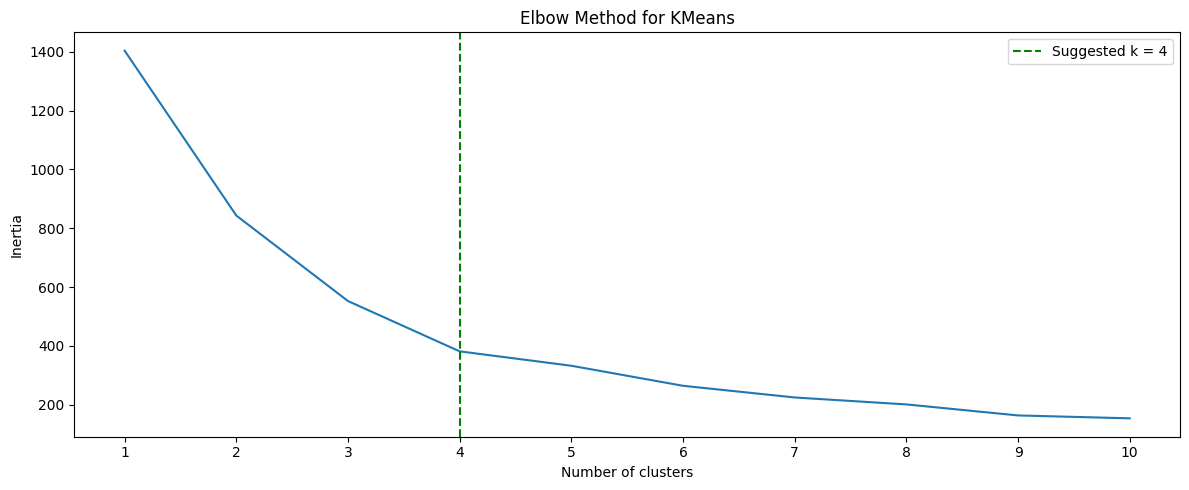

Suggested elbow point: 4
Saved figure to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\outputs\figures\elbow_method.png


In [ ]:
def elbow_optimizer(inertias, label):
    kl = KneeLocator(range(1, 11), inertias, curve="convex", direction="decreasing")

    plt.figure(figsize=(12, 5))
    sns.lineplot(x=range(1, 11), y=inertias)
    plt.xticks(range(1, 11))
    plt.xlabel("Number of clusters")
    plt.ylabel("Inertia")
    plt.title(f"Elbow Method for {label}")

    if kl.elbow:
        plt.axvline(x=kl.elbow, color="green", linestyle="--", label=f"Suggested k = {kl.elbow}")
        plt.legend()

    plt.tight_layout()
    elbow_path = FIGURES_DIR / "elbow_method.png"
    plt.savefig(elbow_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Suggested elbow point: {kl.elbow}")
    print(f"Saved figure to: {elbow_path}")
    return kl.elbow

optimal_k = elbow_optimizer(inertias, "KMeans")

#### Hierarchical Model

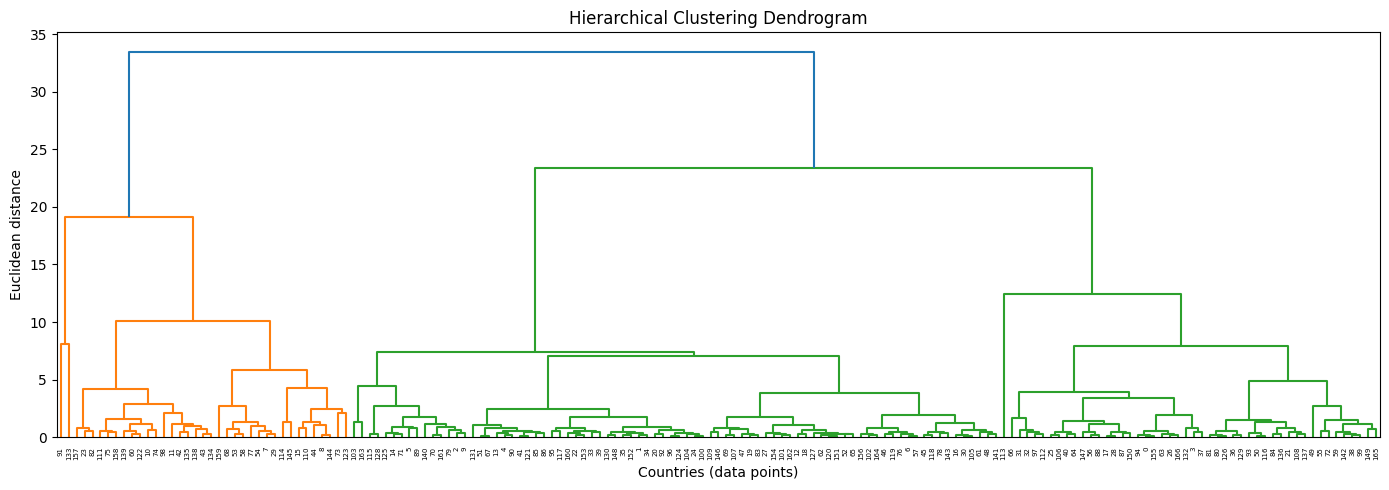

Saved figure to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\outputs\figures\hierarchical_dendrogram.png


In [ ]:
def dendo(data):
    plt.figure(figsize=(14, 5))
    sch.dendrogram(sch.linkage(data, method="ward", metric="euclidean"))
    plt.axhline(y=115, color="#3E3B39", linestyle="--")
    plt.title("Hierarchical Clustering Dendrogram")
    plt.xlabel("Countries (data points)")
    plt.ylabel("Euclidean distance")
    plt.tight_layout()

    dendrogram_path = FIGURES_DIR / "hierarchical_dendrogram.png"
    plt.savefig(dendrogram_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure to: {dendrogram_path}")

dendo(pcadff)

### Clustering Data

In [ ]:
df_cluster = df.copy().set_index(keys="country", drop=True)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_data)

df_cluster["cluster"] = kmeans.labels_
df_cluster.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
country,,,,,,,,,,
Afghanistan,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553,0
Albania,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090,2
Algeria,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460,2
Angola,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530,0
Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200,2


In [ ]:
label_map = {
    0: "High Need for Assistance",
    1: "Low Need for Assistance",
    2: "Moderate Need for Assistance",
}

df_cluster["cluster"] = df_cluster["cluster"].map(label_map)

cluster_assignments_path = DATA_PROCESSED_DIR / "country_cluster_assignments.csv"
df_cluster.reset_index().to_csv(cluster_assignments_path, index=False)

print(f"Saved cluster assignments to: {cluster_assignments_path}")
df_cluster.head()

Saved cluster assignments to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\data\processed\country_cluster_assignments.csv


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
country,,,,,,,,,,
Afghanistan,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553,High Need for Assistance
Albania,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090,Moderate Need for Assistance
Algeria,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460,Moderate Need for Assistance
Angola,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530,High Need for Assistance
Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200,Moderate Need for Assistance


In [ ]:
print(df_cluster['cluster'].value_counts())

cluster
Moderate Need for Assistance    91
High Need for Assistance        48
Low Need for Assistance         28
Name: count, dtype: int64


In [ ]:
clusters = df_cluster.groupby('cluster').apply(lambda x: x.index.tolist())
for cluster, country in clusters.items():
    print(f"Cluster {cluster}:")
    print(", ".join(country))
    print()

Cluster High Need for Assistance:
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Iraq, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, Solomon Islands, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

Cluster Low Need for Assistance:
Australia, Austria, Belgium, Brunei, Canada, Cyprus, Denmark, Finland, France, Germany, Iceland, Ireland, Italy, Japan, Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Qatar, Singapore, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

Cluster Moderate Need for Assistance:
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bahrain, Bangladesh, Barbados, Belarus, Beliz

In [ ]:
df_cluster = df_cluster.reset_index()

color_map = {
    "High Need for Assistance": "red",
    "Low Need for Assistance": "green",
    "Moderate Need for Assistance": "orange",
}

fig = px.choropleth(
    df_cluster,
    locations="country",
    locationmode="country names",
    color="cluster",
    hover_name="country",
    color_discrete_map=color_map,
    title="World Map by Socioeconomic Need Cluster",
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type="equirectangular",
    )
)

cluster_map_path = FIGURES_DIR / "world_clusters_map.html"
fig.write_html(cluster_map_path)
fig.show()

print(f"Saved interactive figure to: {cluster_map_path}")

C:\Users\natha\AppData\Local\Temp\ipykernel_7568\704693085.py:9: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


Saved interactive figure to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\outputs\figures\world_clusters_map.html


In [ ]:
df_cluster = df_cluster.set_index(keys="country", drop=True)
df_cluster.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
country,,,,,,,,,,
Afghanistan,90.2,55.30,41.9174,248.297,1610,9.44,56.2,5.82,553,High Need for Assistance
Albania,16.6,1145.20,267.8950,1987.740,9930,4.49,76.3,1.65,4090,Moderate Need for Assistance
Algeria,27.3,1712.64,185.9820,1400.440,12900,16.10,76.5,2.89,4460,Moderate Need for Assistance
Angola,119.0,2199.19,100.6050,1514.370,5900,22.40,60.1,6.16,3530,High Need for Assistance
Antigua and Barbuda,10.3,5551.00,735.6600,7185.800,19100,1.44,76.8,2.13,12200,Moderate Need for Assistance


### Regression Models with GASearchCV

In [ ]:
df_regression = df.drop("country", axis = 1)
target = df_regression["income"]
features = df_regression.drop("income", axis = 1)

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.3, random_state = 42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [ ]:
models_regression = {
            'LinearRegression': LinearRegression(),
            'DecisionTreeRegressor': DecisionTreeRegressor(),
            'RandomForestRegressor': RandomForestRegressor(),
            'Lasso': Lasso(),
            'Ridge': Ridge(),
            'KNeighborsRegressor': KNeighborsRegressor(),
            'GradientBoostingRegressor': GradientBoostingRegressor()
        }

In [ ]:
param_grid_regression =  {
            'LinearRegression': {
                "copy_X": Categorical([True, False]),
                "fit_intercept": Categorical([True, False]),
                "positive": Categorical([True, False])
            },
            'DecisionTreeRegressor': {
                "max_depth": Integer(3, 10),
                'min_samples_split': Integer(2, 10),
                'min_samples_leaf': Integer(1, 4)
            },
            'RandomForestRegressor': {
                "n_estimators": Integer(50, 100),
                "max_depth": Integer(5, 10),
                'min_samples_split': Integer(2, 5)
            },
            'Lasso': {
                'alpha': Continuous(0.001, 1.0),
                'fit_intercept': Categorical([True, False]),
                'max_iter': Integer(1000, 2000),
                'tol': Continuous(0.0001, 0.001),
                'selection': Categorical(['cyclic', 'random'])
            },
            'Ridge': {
                'alpha': Continuous(0.1, 10.0),
                'fit_intercept': Categorical([True, False]),
                'tol': Continuous(0.0001, 0.001),
                'solver': Categorical(['auto', 'svd', 'cholesky'])
            },
            'KNeighborsRegressor': {
                'n_neighbors': Integer(3, 7),
                'weights': Categorical(['uniform', 'distance']),
                'algorithm': Categorical(['auto', 'ball_tree', 'kd_tree'])
            },
            'GradientBoostingRegressor': {
                'learning_rate': Continuous(0.01, 0.1),
                'n_estimators': Integer(50, 100),
                'max_depth': Integer(3, 5),
                'subsample': Continuous(0.8, 1.0)
            }
        }

In [ ]:
benchmark_results_regression = []

for name, model in models_regression.items():
    print(f"\nEntrenando {name} con método genético...")
    
    evolved_estimator = GASearchCV(
        estimator=model,
        cv=5,
        scoring="r2",
        population_size=10,
        generations=8,
        tournament_size=5,
        elitism=True,
        crossover_probability=0.8,
        mutation_probability=0.1,
        param_grid=param_grid_regression[name],
        criteria="max",
        n_jobs=1,
        verbose=False
    )
    
    evolved_estimator.fit(X_train_scaled, y_train)
    pred = evolved_estimator.predict(X_test_scaled)
    r_squared = r2_score(y_test, pred)

    print(evolved_estimator.best_params_)
    print("r-squared:", "{:.4f}".format(r_squared))

    benchmark_results_regression.append({
        "Model": name,
        "r-squared": float(r_squared)
    })

benchmark_results_regression = pd.DataFrame(benchmark_results_regression)
benchmark_results_regression["r-squared"] = pd.to_numeric(
    benchmark_results_regression["r-squared"],
    errors="coerce"
)

regression_results_path = RESULTS_DIR / "regression_benchmark_results.csv"
benchmark_results_regression.to_csv(regression_results_path, index=False)

print(f"Saved regression benchmark results to: {regression_results_path}")
print(benchmark_results_regression)


Entrenando LinearRegression con método genético...


{'copy_X': True, 'fit_intercept': True, 'positive': False}
r-squared: 0.8730

Entrenando DecisionTreeRegressor con método genético...
{'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 3}
r-squared: 0.8351

Entrenando RandomForestRegressor con método genético...
{'n_estimators': 84, 'max_depth': 7, 'min_samples_split': 2}
r-squared: 0.8887

Entrenando Lasso con método genético...


c:\Users\natha\miniconda3\envs\ds_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.279e+07, tolerance: 8.192e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\natha\miniconda3\envs\ds_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.857e+08, tolerance: 5.661e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\natha\miniconda3\envs\ds_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularis

{'alpha': np.float64(0.30539064339106226), 'fit_intercept': True, 'max_iter': 1809, 'tol': np.float64(0.00019973160301535312), 'selection': 'cyclic'}
r-squared: 0.8733

Entrenando Ridge con método genético...
{'alpha': np.float64(3.1640851600780366), 'fit_intercept': True, 'tol': np.float64(0.00032479424041951475), 'solver': 'cholesky'}
r-squared: 0.9257

Entrenando KNeighborsRegressor con método genético...
{'n_neighbors': 5, 'weights': 'distance', 'algorithm': 'auto'}
r-squared: 0.9352

Entrenando GradientBoostingRegressor con método genético...
{'learning_rate': np.float64(0.0906279455707828), 'n_estimators': 71, 'max_depth': 3, 'subsample': np.float64(0.8339610043440319)}
r-squared: 0.9202
Saved regression benchmark results to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\outputs\results\regression_benchmark_results.csv
                       Model  r-squared
0           LinearRegression   0.873009
1      DecisionTreeRegressor   0.835064
2      Ran

### Classification Models with GASearchCV

In [ ]:
df_classification = df_cluster.copy()
target = df_classification["cluster"]
features = df_classification.drop("cluster", axis = 1)

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.3, random_state = 42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [ ]:
models_classification = {
            'KNeighborsClassifier': KNeighborsClassifier(),
            'DecisionTreeClassifier': DecisionTreeClassifier(),
            'RandomForestClassifier': RandomForestClassifier(),
            'AdaBoostClassifier': AdaBoostClassifier(),
            'GradientBoostingClassifier': GradientBoostingClassifier()
        }

In [ ]:
param_grid_classification =  {
            'KNeighborsClassifier': {
                'n_neighbors': Integer(3, 7),
                'weights': Categorical(['uniform', 'distance']),
                'algorithm': Categorical(['auto', 'ball_tree', 'kd_tree'])
            },
            'DecisionTreeClassifier': {
                "max_depth": Integer(3, 10),
                'min_samples_split': Integer(2, 10),
                'min_samples_leaf': Integer(1, 4)
            },
            'RandomForestClassifier': {
                "n_estimators": Integer(50, 100),
                "max_depth": Integer(5, 10),
                'min_samples_split': Integer(2, 5)
            },
            'AdaBoostClassifier': {
                'learning_rate': Continuous(0.01, 0.1),
                'n_estimators': Integer(50, 100)
            },
            'GradientBoostingClassifier': {
                'learning_rate': Continuous(0.01, 0.1),
                'n_estimators': Integer(50, 100),
                'max_depth': Integer(3, 5),
                'subsample': Continuous(0.8, 1.0)
            }
        }

In [ ]:
benchmark_results_classification = []

for name, model in models_classification.items():
    print(f"\nEntrenando {name} con método genético...")
    
    evolved_estimator = GASearchCV(
        estimator=model,
        cv=5,
        scoring="accuracy",
        population_size=10,
        generations=8,
        tournament_size=5,
        elitism=True,
        crossover_probability=0.8,
        mutation_probability=0.1,
        param_grid=param_grid_classification[name],
        criteria="max",
        n_jobs=1,
        verbose=False
    )
    
    evolved_estimator.fit(X_train_scaled, y_train)
    pred = evolved_estimator.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, pred)

    print(evolved_estimator.best_params_)
    print("accuracy:", "{:.4f}".format(accuracy))

    benchmark_results_classification.append({
        "Model": name,
        "Accuracy": float(accuracy)
    })

benchmark_results_classification = pd.DataFrame(benchmark_results_classification)
benchmark_results_classification["Accuracy"] = pd.to_numeric(
    benchmark_results_classification["Accuracy"],
    errors="coerce"
)

classification_results_path = RESULTS_DIR / "classification_benchmark_results.csv"
benchmark_results_classification.to_csv(classification_results_path, index=False)

print(f"Saved classification benchmark results to: {classification_results_path}")
print(benchmark_results_classification)


Entrenando KNeighborsClassifier con método genético...
{'n_neighbors': 5, 'weights': 'distance', 'algorithm': 'auto'}
accuracy: 0.9608

Entrenando DecisionTreeClassifier con método genético...
{'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 1}
accuracy: 0.9608

Entrenando RandomForestClassifier con método genético...
{'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 4}
accuracy: 0.9804

Entrenando AdaBoostClassifier con método genético...
{'learning_rate': np.float64(0.08459566135485327), 'n_estimators': 99}
accuracy: 0.9412

Entrenando GradientBoostingClassifier con método genético...
{'learning_rate': np.float64(0.0588255866151331), 'n_estimators': 85, 'max_depth': 3, 'subsample': np.float64(0.8430067338448664)}
accuracy: 0.9608
Saved classification benchmark results to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\outputs\results\classification_benchmark_results.csv
                        Model  Accuracy
0        KNeighborsCla

### Benchmark Results and Wilcoxon Test

In [ ]:
from IPython.display import display

print("\nRegression Benchmark Results:")
display(benchmark_results_regression)


Regression Benchmark Results:


,Model,r-squared
0,LinearRegression,0.873009
1,DecisionTreeRegressor,0.835064
2,RandomForestRegressor,0.888686
3,Lasso,0.873253
4,Ridge,0.925746
5,KNeighborsRegressor,0.935170
6,GradientBoostingRegressor,0.920217


In [ ]:
stats_regression = pd.to_numeric(
    benchmark_results_regression["r-squared"],
    errors="coerce"
).dropna().to_numpy(dtype=float)

wilcoxon_regression = stats.wilcoxon(stats_regression)

wilcoxon_regression_path = RESULTS_DIR / "wilcoxon_regression_results.txt"
with open(wilcoxon_regression_path, "w", encoding="utf-8") as file:
    file.write(str(wilcoxon_regression))

print(wilcoxon_regression)
print(f"Saved Wilcoxon regression results to: {wilcoxon_regression_path}")

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.015625))
Saved Wilcoxon regression results to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\outputs\results\wilcoxon_regression_results.txt


H0similar: The performance evaluations of the six regression models are similar.
H1similar: The performance evaluations of the six regression models are not similar.

For the six regression models, the p-value = 0.0156 < alpha = 0.05.
This indicates a statistically significant difference in the performance evaluations of these models.
Therefore, our approach shows variability across the models.

In [ ]:
print("\nClassification Benchmark Results:")
display(benchmark_results_classification)


Classification Benchmark Results:


,Model,Accuracy
0,KNeighborsClassifier,0.960784
1,DecisionTreeClassifier,0.960784
2,RandomForestClassifier,0.980392
3,AdaBoostClassifier,0.941176
4,GradientBoostingClassifier,0.960784


In [ ]:
stats_classification = pd.to_numeric(
    benchmark_results_classification["Accuracy"],
    errors="coerce"
).dropna().to_numpy(dtype=float)

wilcoxon_classification = stats.wilcoxon(stats_classification)

wilcoxon_classification_path = RESULTS_DIR / "wilcoxon_classification_results.txt"
with open(wilcoxon_classification_path, "w", encoding="utf-8") as file:
    file.write(str(wilcoxon_classification))

print(wilcoxon_classification)
print(f"Saved Wilcoxon classification results to: {wilcoxon_classification_path}")

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.0625))
Saved Wilcoxon classification results to: C:\Users\natha\Documents\DataScience\projects\global-socioeconomic-ml-analysis\outputs\results\wilcoxon_classification_results.txt


H0similar: The performance evaluations of the four classification models are similar.
H1similar: The performance evaluations of the four classification models are not similar.

For the four classification models, the p-value = 0.0625 > alpha = 0.05.
This indicates that there is no statistically significant difference in the performance evaluations of these models.
Thus, our approach demonstrates consistency across the models.